<a href="https://colab.research.google.com/github/maccadithyan2005-design/Ridge-and-Lass0/blob/main/exp%209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [3]:
# Load Iris dataset
iris = load_iris()

In [4]:
# Petal length and petal width
X = iris.data[:, [2, 3]]

In [5]:
# Setosa = 0, Non-Setosa = 1
y = (iris.target != 0).astype(int)


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# Linear SVM
model = SVC(kernel="linear", C=1)
model.fit(X_train, y_train)


SVC(C=1, kernel='linear')

In [9]:
# Prediction
y_pred = model.predict(X_test)


In [10]:
print("Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")


Accuracy: 100.0 %


In [11]:
# Plot decision boundary
plt.figure(figsize=(8, 6))

x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5
y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5


<Figure size 800x600 with 0 Axes>

In [12]:
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


In [13]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

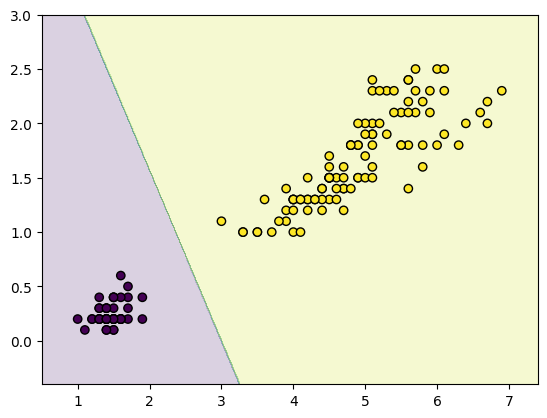

In [14]:
plt.contourf(xx, yy, Z, alpha=0.2)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")


In [15]:
w = model.coef_[0]
b = model.intercept_[0]

In [16]:
x_values = np.linspace(x_min, x_max, 100)
decision_boundary = -(w[0] * x_values + b) / w[1]


In [17]:
margin = 1 / np.sqrt(np.sum(w ** 2))
upper_margin = decision_boundary + margin
lower_margin = decision_boundary - margin


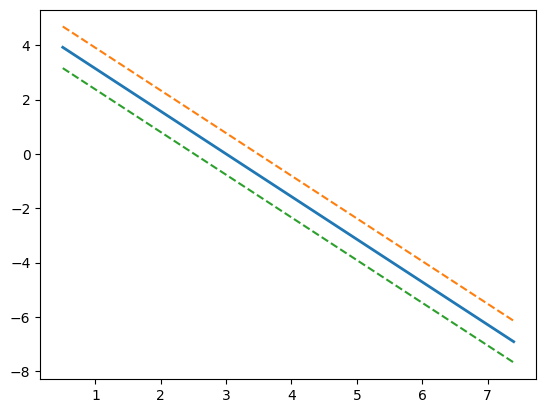

In [18]:
plt.plot(x_values, decision_boundary,
         linewidth=2, label="Decision Boundary")
plt.plot(x_values, upper_margin, "--", label="Margin")
plt.plot(x_values, lower_margin, "--")

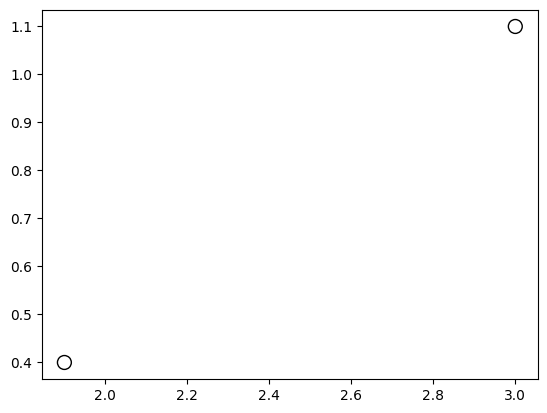

In [19]:
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=100, facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)